In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("Books_Data_Clean.csv")

In [35]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


***Data Cleaning and Processing***

In [36]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [37]:
df  = df[df['Publishing Year'] > 1900]

In [38]:
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,21
Author,0
language_code,49
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [39]:
df.dropna(subset = "Book Name", inplace = True)

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.nunique()

,0
index,988
Publishing Year,101
Book Name,987
Author,669
language_code,8
Author_Rating,4
Book_average_rating,133
Book_ratings_count,983
genre,4
gross sales,774


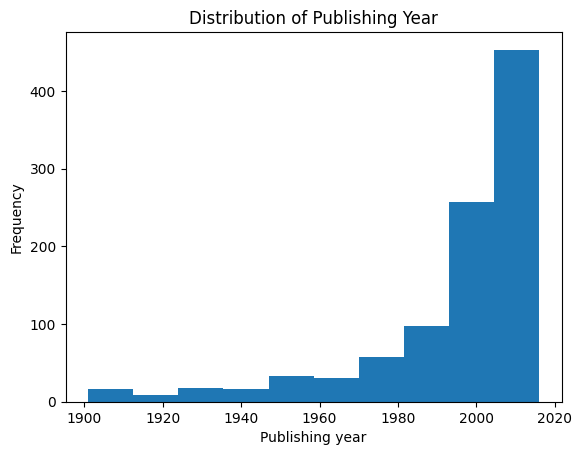

In [42]:
plt.hist(df['Publishing Year'])

plt.xlabel("Publishing year")

plt.ylabel("Frequency")

plt.title("Distribution of Publishing Year")

plt.show()

***From the above histogram we can say that most books are published during 2000-2020***

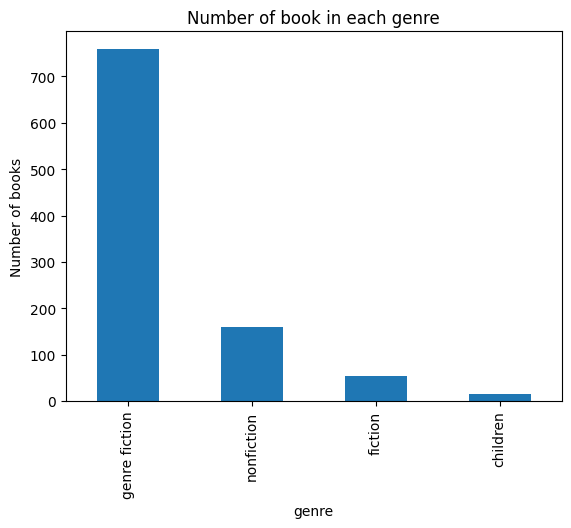

In [43]:
df["genre"].value_counts().plot(kind="bar")

plt.xlabel("genre")

plt.ylabel("Number of books")

plt.title("Number of book in each genre")

plt.show()

***Genre Fiction has most count followed by non-fiction, fiction and children***

In [44]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False)

,Book_average_rating
Author,
Bill Watterson,4.650000
"Bill Watterson, G.B. Trudeau",4.610000
J.R.R. Tolkien,4.590000
George R.R. Martin,4.560000
Sarah J. Maas,4.526000
...,...
Chetan Bhagat,3.273333
Audrey Niffenegger,3.230000
"Herman Koch, Sam Garrett",3.220000


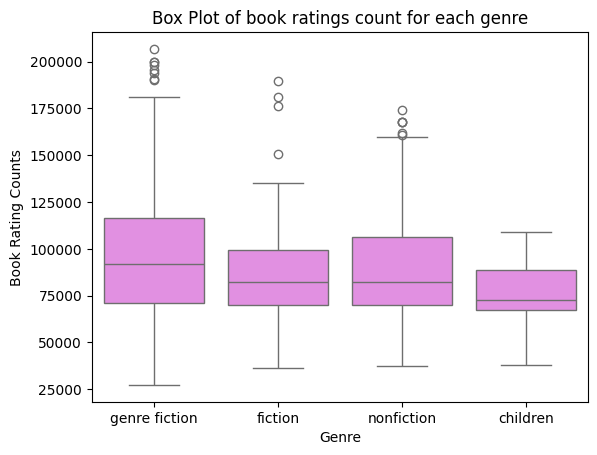

In [45]:
sns.boxplot(x="genre" , y = "Book_ratings_count", data = df, color = "violet")

plt.xlabel("Genre")

plt.ylabel("Book Rating Counts")

plt.title("Box Plot of book ratings count for each genre")

plt.show()

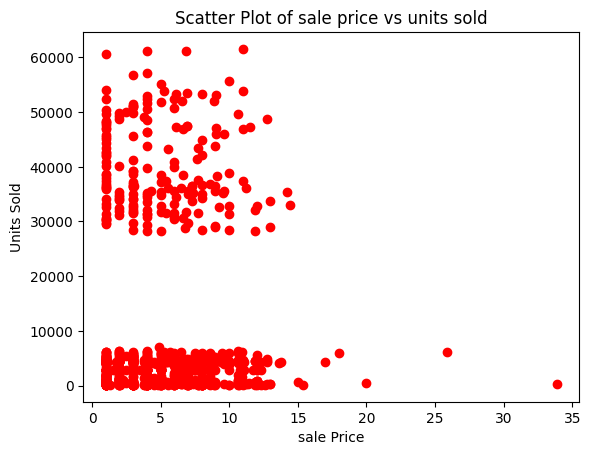

In [46]:
plt.scatter(df["sale price"], df["units sold"], color = "red")

plt.xlabel("sale Price")

plt.ylabel("Units Sold")

plt.title("Scatter Plot of sale price vs units sold")

plt.show()

High-selling books mostly fall under $2–$8.

In [47]:
language_counts = df["language_code"].value_counts().sort_values()

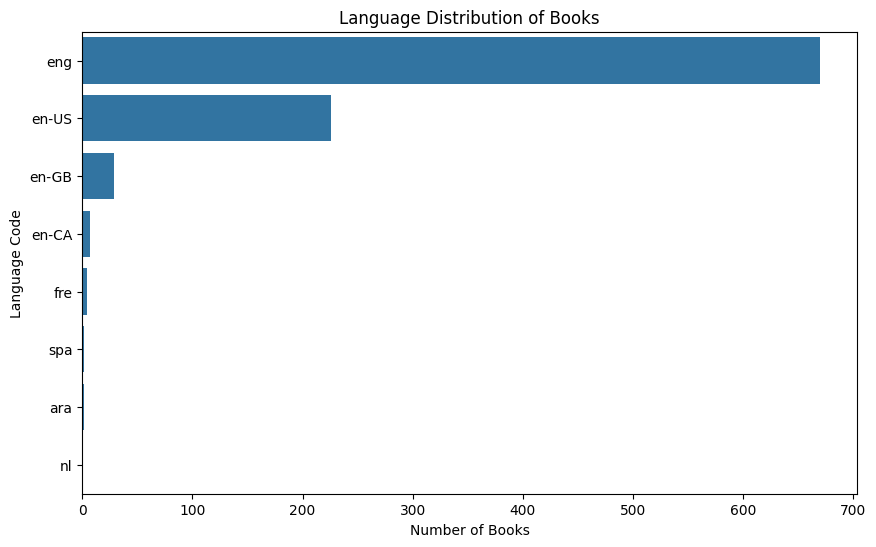

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

language_counts = df['language_code'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=language_counts.values, y=language_counts.index)
plt.title("Language Distribution of Books")
plt.xlabel("Number of Books")
plt.ylabel("Language Code")
plt.show()



*It is clear that language in which books are mostly published is english*


In [49]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending=False)

,publisher revenue
Publisher,
Penguin Group (USA) LLC,191581.104
Random House LLC,174956.244
"Amazon Digital Services, Inc.",141767.772
HarperCollins Publishers,121769.814
Hachette Book Group,107410.968
Simon and Schuster Digital Sales Inc,46858.206
Macmillan,31249.830
HarperCollins Publishing,2830.806
HarperCollins Christian Publishing,2135.670


***Publisher who is generating the most revenue is Penguin Group (USA) LLC***

In [50]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending = False).max()

101400.27256944444

In [51]:
df.groupby("language_code").size().sort_values(ascending = False)

,0
language_code,
eng,670
en-US,226
en-GB,29
en-CA,7
fre,4
ara,2
spa,2
nl,1


In [52]:
df.groupby("Author_Rating")["Book_ratings_count"].max()

,Book_ratings_count
Author_Rating,
Excellent,167848
Famous,206792
Intermediate,199872
Novice,155903


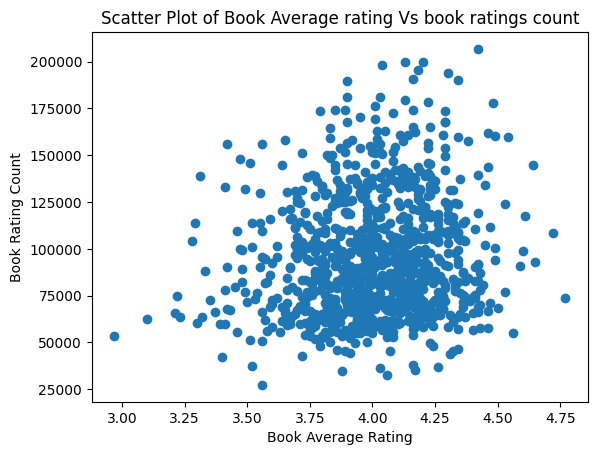

In [53]:
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])

plt.xlabel("Book Average Rating")

plt.ylabel("Book Rating Count")

plt.title("Scatter Plot of Book Average rating Vs book ratings count")

plt.show()

***The average rating of book lies between 3.75 to 4.25 on an average***

In [54]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()

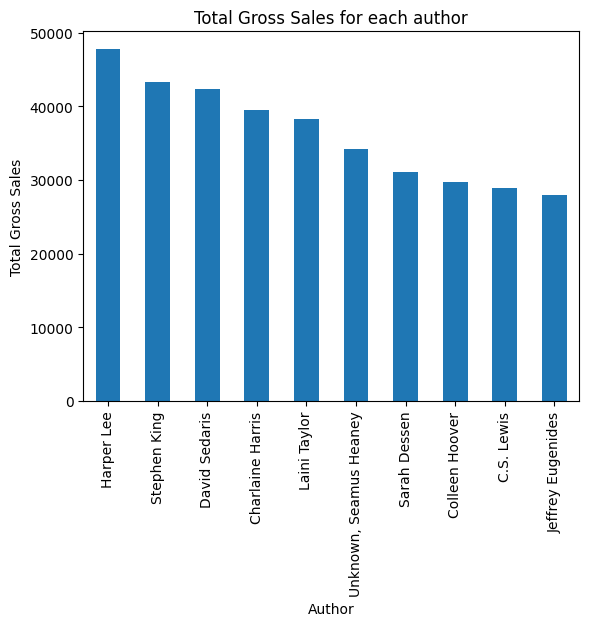

In [55]:
total_gross_sales_by_author.sort_values(ascending = False).head(10).plot(kind = "bar")

plt.xlabel("Author")

plt.ylabel("Total Gross Sales")

plt.title("Total Gross Sales for each author")

plt.show()


***Harper Lee stands first in case of total gross sale of each author***

/tmp/ipython-input-1225895613.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Author_Rating", y="units sold", data=df, palette = "pastel")


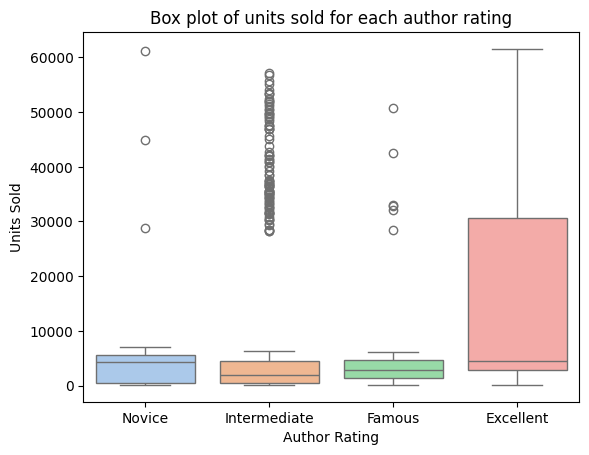

In [67]:


sns.boxplot(x="Author_Rating", y="units sold", data=df, palette = "pastel")

plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box plot of units sold for each author rating")
plt.show()


***1 Excellent-rated authors sell dramatically more units — their median and spread are far higher than Novice, Intermediate, and Famous authors, with many extreme high-selling outliers.***

***2️ Lower author ratings (Novice, Intermediate, Famous) show consistently low and tightly clustered sales, indicating limited variability and overall lower market reach compared to top-rated authors***.

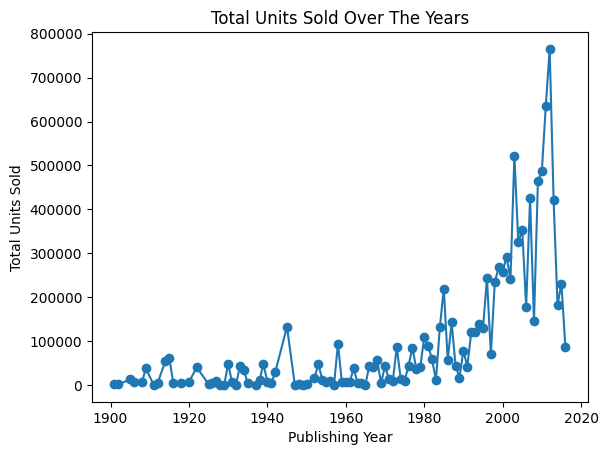

In [69]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind = "line", marker = "o")

plt.xlabel("Publishing Year")

plt.ylabel("Total Units Sold")

plt.title("Total Units Sold Over The Years")

plt.show()


The majority of publishing is between 2000 to 2020 which is about 800000